In [1]:
import numpy as np

from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic(
        "config", "InlineBackend.rc = {'figure.dpi': 300}"
    )  # choose a value you like

# P(E) / DCB

In [2]:
import numpy as np
from scipy.special import gammaln


# P(E) ohmic kernel
def get_Penv_meV(Eenv_meV, R_kOhm, nuc_GHz):
    """
    Zero-temperature Ohmic P(E) cutoff model.

    Parameters
    ----------
    E_meV : float or array
        Exchanged energy in meV.
    R_kOhm : float
        Ohmic environmental resistance in kOhm.
    nuc_GHz : float
        Cutoff frequency nu_c in GHz. Uses E_c = h nu_c.

    Returns
    -------
    P : float or array
        P(E) in 1/meV.
    """
    E = np.asarray(Eenv_meV, dtype=float)
    dE = E[1] - E[0]

    if R_kOhm == 0.0:
        P = np.zeros_like(E)
        i0 = np.argmin(np.abs(E))
        P[i0] = 1.0 / dE
    else:
        Ec = sc.h_pVs * nuc_GHz
        alpha = 4.0e-3 * R_kOhm * sc.G0_muS

        P = np.zeros_like(E, dtype=float)
        mask = E > 0

        # P(E) = 1/(Ec Gamma(alpha)) * (E/Ec)^(alpha-1) * exp(-E/Ec)
        x = E[mask] / Ec
        logP = -np.log(Ec) - gammaln(alpha) + (alpha - 1.0) * np.log(x) - x
        P[mask] = np.exp(logP)

    P /= np.trapezoid(P, E)
    if np.isscalar(Eenv_meV):
        return float(P)

    return P


# A12, A21 Kernel
def get_A_meV(
    E_meV: NDArray64,
    T1_K: float,
    T2_K: float,
    Delta1_meV: float,
    Delta2_meV: float,
    gamma1_meV: float,
    gamma2_meV: float,
):
    dE_meV = float(E_meV[1] - E_meV[0])
    DeltaT1_meV = sc.get_DeltaT_meV(Delta1_meV, T1_K)
    DeltaT2_meV = sc.get_DeltaT_meV(Delta2_meV, T2_K)
    dos1 = sc.get_dos(E_meV, DeltaT1_meV, gamma1_meV)
    dos2 = sc.get_dos(E_meV, DeltaT2_meV, gamma2_meV)
    occupied1 = dos1 * sc.get_f(E_meV, T1_K)
    occupied2 = dos2 * sc.get_f(E_meV, T2_K)
    empty1 = dos1 * (1.0 - sc.get_f(E_meV, T1_K))
    empty2 = dos2 * (1.0 - sc.get_f(E_meV, T2_K))
    A12_meV = np.correlate(empty2, occupied1, mode="full") * dE_meV
    A21_meV = np.correlate(empty1, occupied2, mode="full") * dE_meV
    E0_meV = np.arange(-(E_meV.size - 1), E_meV.size, dtype=np.float64) * dE_meV
    return A12_meV, A21_meV, E0_meV


# DCB I(V) Kernel
def dcb_current_np(
    V_mV: NDArray64,
    E0_meV: NDArray64,
    A12_meV: NDArray64,
    A21_meV: NDArray64,
    Eenv_meV: NDArray64,
    Penv_meV: NDArray64,
):
    V_mV = np.asarray(V_mV, dtype=np.float64)
    E0_meV = np.asarray(E0_meV, dtype=np.float64)
    A12_meV = np.asarray(A12_meV, dtype=np.float64)
    A21_meV = np.asarray(A21_meV, dtype=np.float64)
    Penv_meV = np.asarray(Penv_meV, dtype=np.float64)
    Eenv_meV = np.asarray(Eenv_meV, dtype=np.float64)

    Gamma12 = np.zeros_like(V_mV)
    Gamma21 = np.zeros_like(V_mV)

    for i, v_mV in enumerate(V_mV):
        U12env_meV = -Eenv_meV + v_mV
        U21env_meV = -Eenv_meV - v_mV

        A12env_meV = np.interp(x=U12env_meV, xp=E0_meV, fp=A12_meV, left=0.0, right=0.0)
        A21env_meV = np.interp(x=U21env_meV, xp=E0_meV, fp=A21_meV, left=0.0, right=0.0)

        Gamma12[i] = np.trapezoid(Penv_meV * A12env_meV, Eenv_meV)
        Gamma21[i] = np.trapezoid(Penv_meV * A21env_meV, Eenv_meV)

    return Gamma12 - Gamma21

In [3]:
# T_K, Delta_meV, gamma_meV
T_K = 0.0
Delta_meV = 0.18
gamma_meV = 1e-7

# P(E)
RQ_kOhm = 0.5e3 / sc.G0_muS
R_RQ = np.array([0.0, 0.03, 0.33, 0.66, 1.0])
R_kOhm = R_RQ * RQ_kOhm
nuc_GHz = Delta_meV / sc.h_pVs

Eenv_Delta = np.linspace(0, 4, 5001)
Eenv_meV = Eenv_Delta * Delta_meV
Penv_meV = np.zeros((R_kOhm.shape[0], Eenv_meV.shape[0]))
for i, r_kOhm in enumerate(R_kOhm):
    Penv_meV[i, :] = get_Penv_meV(
        Eenv_meV=Eenv_meV,
        R_kOhm=r_kOhm,
        nuc_GHz=nuc_GHz,
    )

# A12_meV, A21_meV
E_Delta = np.linspace(-4, 4, 100001, dtype=np.float64)
E_meV = E_Delta * Delta_meV
A12sis_meV, A21sis_meV, E0_meV = get_A_meV(
    E_meV=E_meV,
    T1_K=T_K,
    T2_K=T_K,
    Delta1_meV=Delta_meV,
    Delta2_meV=Delta_meV,
    gamma1_meV=gamma_meV,
    gamma2_meV=gamma_meV,
)
A12sin_meV, A21sin_meV, E0_meV = get_A_meV(
    E_meV=E_meV,
    T1_K=T_K,
    T2_K=T_K,
    Delta1_meV=Delta_meV,
    Delta2_meV=0.0,
    gamma1_meV=gamma_meV,
    gamma2_meV=gamma_meV,
)
A12nin_meV, A21nin_meV, E0_meV = get_A_meV(
    E_meV=E_meV,
    T1_K=T_K,
    T2_K=T_K,
    Delta1_meV=0.0,
    Delta2_meV=0.0,
    gamma1_meV=gamma_meV,
    gamma2_meV=gamma_meV,
)

# Idcb_nA
GN_G0 = 1.0
V_Delta = np.linspace(0, 4, 1001)
V_mV = V_Delta * Delta_meV

Isis_nA = np.zeros((R_kOhm.shape[0], V_mV.shape[0]))
Isin_nA = np.zeros((R_kOhm.shape[0], V_mV.shape[0]))
Inin_nA = np.zeros((R_kOhm.shape[0], V_mV.shape[0]))

for i, r_kOhm in enumerate(R_kOhm):
    Isis_nA[i, :] = dcb_current_np(
        V_mV=V_mV,
        E0_meV=E0_meV,
        A12_meV=A12sis_meV,
        A21_meV=A21sis_meV,
        Penv_meV=Penv_meV[i, :],
        Eenv_meV=Eenv_meV,
    )
    Isin_nA[i, :] = dcb_current_np(
        V_mV=V_mV,
        E0_meV=E0_meV,
        A12_meV=A12sin_meV,
        A21_meV=A21sin_meV,
        Penv_meV=Penv_meV[i, :],
        Eenv_meV=Eenv_meV,
    )
    Inin_nA[i, :] = dcb_current_np(
        V_mV=V_mV,
        E0_meV=E0_meV,
        A12_meV=A12nin_meV,
        A21_meV=A21nin_meV,
        Penv_meV=Penv_meV[i, :],
        Eenv_meV=Eenv_meV,
    )

In [4]:
# import matplotlib.pyplot as plt

# plt.figure(0)
# for i, r_kOhm in enumerate(R_kOhm):
#     plt.semilogy(Eenv_meV, Penv_meV[i, :], ".")

In [5]:
# plt.figure(0)
# for i, r_kOhm in enumerate(R_kOhm):
#     plt.plot(V_mV / Delta_meV, Isis_nA[i, :] / Delta_meV)
#     plt.plot(V_mV / Delta_meV, Isin_nA[i, :] / Delta_meV)
#     plt.plot(V_mV / Delta_meV, Inin_nA[i, :] / Delta_meV)
# # plt.ylim(-1, 2)

In [6]:
# plt.figure(0)
# for i, r_kOhm in enumerate(R_kOhm):
#     plt.plot(V_mV, np.gradient(Isis_nA[i, :] / Delta_meV, V_mV / Delta_meV))
#     plt.plot(V_mV, np.gradient(Isin_nA[i, :] / Delta_meV, V_mV / Delta_meV))
#     plt.plot(V_mV, np.gradient(Inin_nA[i, :] / Delta_meV, V_mV / Delta_meV))
# plt.ylim(-0.1, 10)

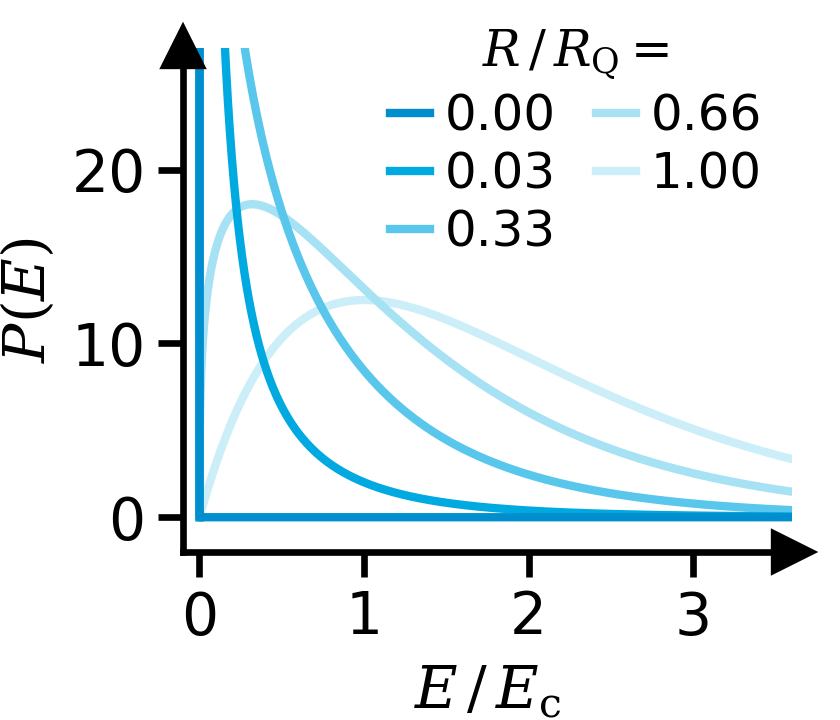

In [7]:
# P(E)
fig, ax = sc.get_figure(figsize=(1.4, 1.2), padding=(0.225, 0.2))

for i, r_RQ in enumerate(R_RQ):
    ax.plot(
        Eenv_meV / (Delta_meV),
        Penv_meV[i, :] / Delta_meV,
        color=sc.seeblau[i],
        zorder=-i,
        label=f"{r_RQ:1.2f}",
    )

ax.legend(
    title="$R\\,/\\,R_\\mathrm{Q} = $",
    handlelength=0.8,
    loc="upper right",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=2,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.2,  # reduces vertical spacing between items
    handletextpad=0.3,  # reduces spacing between line and label
    bbox_to_anchor=(1.0, 1.1),
)

ax.set_xlim(-0.1, 3.6)
ax.set_xticks([0, 1, 2, 3])

ax.set_ylim(-2, 27)

xlabel = "$E\\,/\\,E_\\mathrm{c}$"
ylabel = "$P(E)$"
title = "theory/stochastic/pe"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

In [8]:
figsize = (1.3, 1.2)

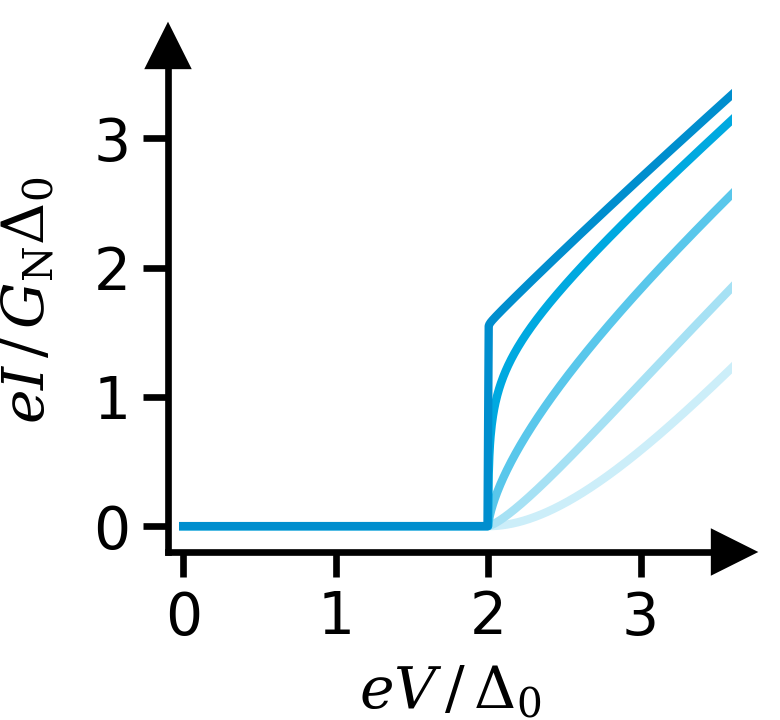

In [9]:
fig, ax = sc.get_figure(figsize=figsize)

for i, r_RQ in enumerate(R_RQ):
    ax.plot(
        V_mV / Delta_meV,
        Isis_nA[i, :] / Delta_meV,
        color=sc.seeblau[i],
        zorder=5 - i,
        label=f"{r_RQ:1.2f}",
    )

ax.set_xlim(-0.1, 3.6)
ax.set_xticks([0, 1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$eI\\,/\\,G_\\mathrm{N}\\Delta_0$"
title = "theory/stochastic/iv-sis"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

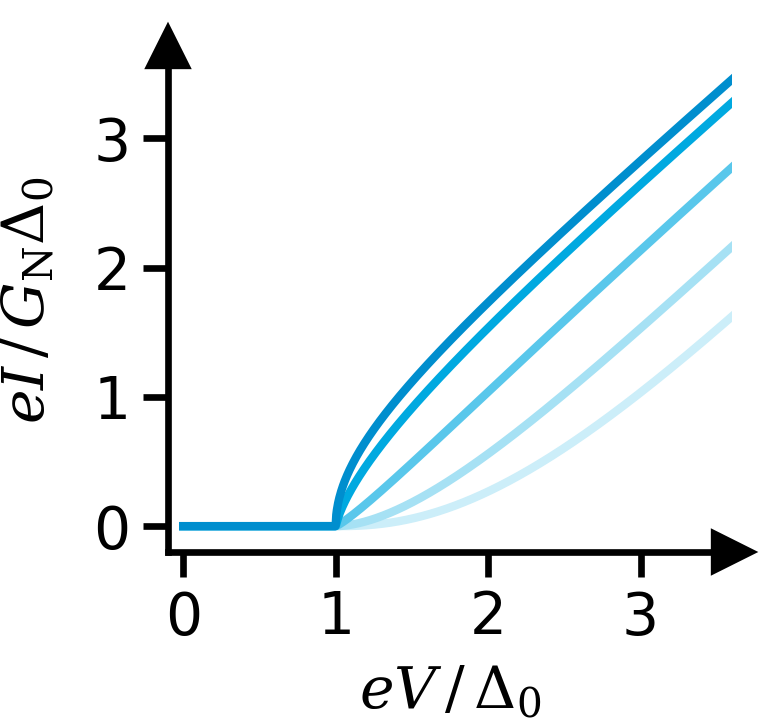

In [10]:
fig, ax = sc.get_figure(figsize=figsize)

for i, r_RQ in enumerate(R_RQ):
    ax.plot(
        V_mV / Delta_meV,
        Isin_nA[i, :] / Delta_meV,
        color=sc.seeblau[i],
        zorder=5 - i,
        label=f"{r_RQ:1.2f}",
    )

ax.set_xlim(-0.1, 3.6)
ax.set_xticks([0, 1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$eI\\,/\\,G_\\mathrm{N}\\Delta_0$"
title = "theory/stochastic/iv-sin"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

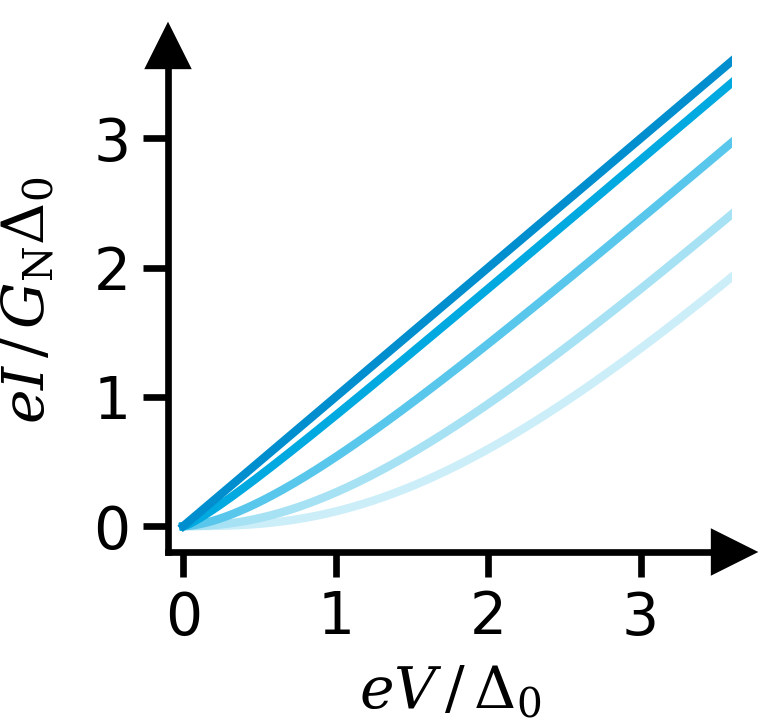

In [11]:
fig, ax = sc.get_figure(figsize=figsize)

for i, r_RQ in enumerate(R_RQ):
    ax.plot(
        V_mV / Delta_meV,
        Inin_nA[i, :] / Delta_meV,
        color=sc.seeblau[i],
        zorder=5 - i,
        label=f"{r_RQ:1.2f}",
    )

ax.set_xlim(-0.1, 3.6)
ax.set_xticks([0, 1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$eI\\,/\\,G_\\mathrm{N}\\Delta_0$"
title = "theory/stochastic/iv-nin"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

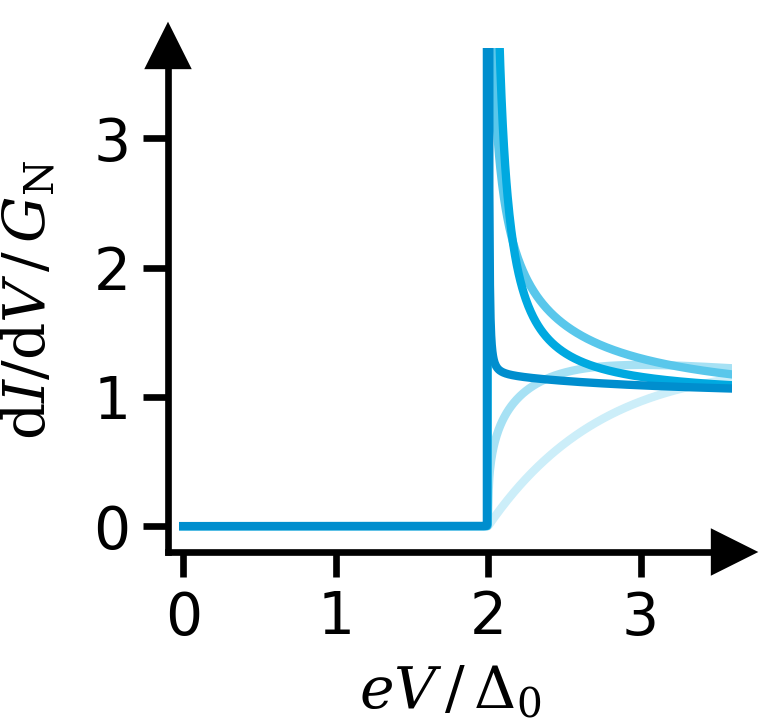

In [12]:
fig, ax = sc.get_figure(figsize=figsize)

for i, r_RQ in enumerate(R_RQ):
    ax.plot(
        V_mV / Delta_meV,
        np.gradient(Isis_nA[i, :] / Delta_meV, V_mV / Delta_meV),
        color=sc.seeblau[i],
        zorder=5 - i,
        label=f"{r_RQ:1.2f}",
    )

ax.set_xlim(-0.1, 3.6)
ax.set_xticks([0, 1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$"
title = "theory/stochastic/didv-sis"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

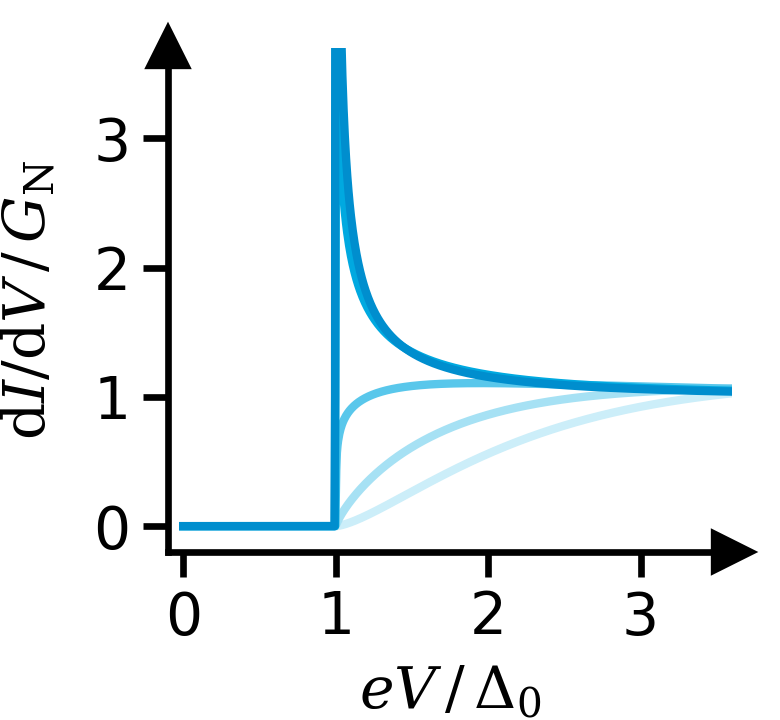

In [13]:
fig, ax = sc.get_figure(figsize=figsize)

for i, r_RQ in enumerate(R_RQ):
    ax.plot(
        V_mV / Delta_meV,
        np.gradient(Isin_nA[i, :] / Delta_meV, V_mV / Delta_meV),
        color=sc.seeblau[i],
        zorder=5 - i,
        label=f"{r_RQ:1.2f}",
    )

ax.set_xlim(-0.1, 3.6)
ax.set_xticks([0, 1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$"
title = "theory/stochastic/didv-sin"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

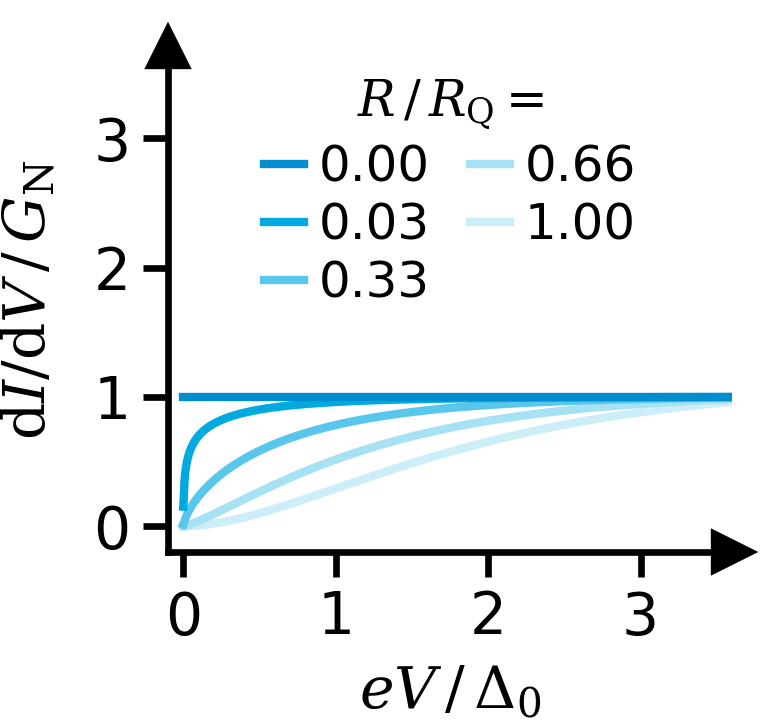

In [14]:
fig, ax = sc.get_figure(figsize=figsize)

for i, r_RQ in enumerate(R_RQ):
    ax.plot(
        V_mV / Delta_meV,
        np.gradient(Inin_nA[i, :] / Delta_meV, V_mV / Delta_meV),
        color=sc.seeblau[i],
        zorder=5 - i,
        label=f"{r_RQ:1.2f}",
    )


ax.legend(
    title="$R\\,/\\,R_\\mathrm{Q} = $",
    handlelength=0.8,
    loc="upper center",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=2,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.2,  # reduces vertical spacing between items
    handletextpad=0.3,  # reduces spacing between line and label
    # bbox_to_anchor=(0.01, 1.1),
)

ax.set_xlim(-0.1, 3.6)
ax.set_xticks([0, 1, 2, 3])

ax.set_ylim(-0.2, 3.7)
ax.set_yticks([0, 1, 2, 3])

xlabel = "$eV\\,/\\,\\Delta_0$"
ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$"
title = "theory/stochastic/didv-nin"

sc.theory_layout(fig, ax, title, xlabel, ylabel)